# 1. INTRODUCTION AND CONTEXT
The goal of this analysis is to investigate the disposable income around each Metro Station in Paris, to answer the following research questions:

    What’s the distribution of average disposable income?
    Which Metro Line is the richest on average?
    Which Metro Line is the poorest on average?
    Which Metro Line is the most unequal on average?

To answer this question, the following Data is used:
- Disposable Income Dataset of the French Gouverment: https://entrepot.recherche.data.gouv.fr/dataset.xhtml?persistentId=doi:10.57745/QRBINB ; The geotif raster was cropped and reprojected to a metric coordinate system using QGIS beforehand.

- Shapefile of Stations, also provided by the french gouverment : https://www.data.gouv.fr/datasets/gares-et-stations-du-reseau-ferre-dile-de-france-par-ligne

- Shapefile of Metrolines, also provided by the french goverment : https://www.data.gouv.fr/datasets/itineraires-de-metro-dans-openstreetmap


## METHODOLOGY
The methodology is to create a 400 m buffer around the stations, use it as a simplified catchment area, and calculate the spatial statistic of average income. It should be noted that this approach is also simplified, as it does not account for the proportion of each grid cell covered by the buffer. So if a buffer touches 2 grids, it will be the unweighted average of both, regardless of how much of each cell is covered

If a station is an interchange between several lines, it is treated as separate stations. This is motivated by two reasons, on the one hand that some tracks between lines are quite far from each other, on the other hand there are actually some notable differences between the same station.

## STRUCTURE OF OUTCOMES 
The project has the following structure:
1. Introduction and Context
2. Imports
3. Data Processing
4. Data Analysis
       
    4.1 Income Distribution

    4.2 Grouping Stations per Line 

    4.3 Income per Line
    
    4.4 Inequality per Line

5. Regression

    5.1 Regression North-South
    
    5.2 Regression West-East

6. Sensitivity Analysis
7. Conclusion 

The chapters generally follow the same structure with three parts:

- Markdown introducing the topic
- Code with prints of the major outcomes
- INTERPRETATION Markdown, summarizing the findings for the specific topic

# 2. IMPORTS
Import Tools, Functions and Data

In [ ]:
#Path Setup
import sys
import os
sys.path.append(os.path.abspath(".."))

#Packages
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import numpy as np
import statsmodels.api as sm

#Functions
from functions.load_data import load_stations, load_income_grid
from functions.raster_analysis import extract_mean_raster_value
from functions.spatial import reproject_to_metric, create_buffers
from functions.load_data import load_metro_lines
from rasterio.plot import show

In [ ]:
#Import the Income Raster
income_raster_path = "../data/FRA_disp_inc_2015_EPSG_2154_crop.tif"

Note: According to my research, automatically downloading and adjusting a TIFF file is quite complicated. This is something I would have implemented with more time and experience.

In [3]:
#Import Station Dataset and filter for the Metro Stations
stations = load_stations(
    "https://data.iledefrance-mobilites.fr/api/explore/v2.1/catalog/datasets/emplacement-des-gares-idf/exports/geojson"
)
stations = reproject_to_metric(stations)
stations = stations[stations["mode"] == "METRO"]

In [4]:
#Import Metro Lines and filter for the Paris ones (Operated by RATP)
metro_lines_url = "https://magosm.magellium.com/geoserver/wfs?request=GetFeature&version=2.0.0&count=500000&outputFormat=application/json&typeName=magosm:subway_routes_line&srsName=EPSG:3857&bbox=-1538728.3025657746,4558105.012117158,2570526.338045301,6805965.139927621"
metro_lines = load_metro_lines(metro_lines_url)
metro_lines = reproject_to_metric(metro_lines)
metro_lines_paris = metro_lines[
    metro_lines["operator"] == "RATP"
].copy()

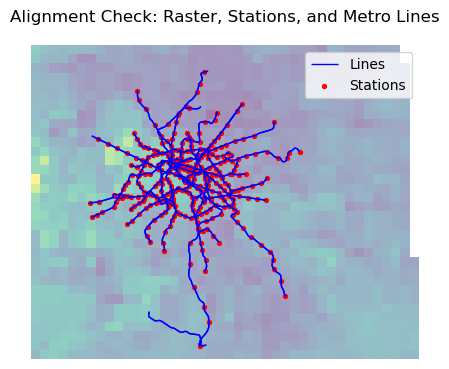

In [ ]:
#Checkup Map to see if Raster, Stations and Lines are in the same system

fig, ax = plt.subplots(figsize=(5,5))
with rasterio.open(income_raster_path) as raster:
    show(raster, ax=ax, cmap="viridis", alpha=0.5)
metro_lines_paris.plot(ax=ax, color="blue", linewidth=1, label="Lines")
stations.plot(ax=ax, color="red", markersize=8, label="Stations")
ax.set_title("Alignment Check: Raster, Stations, and Metro Lines")
ax.set_axis_off()

plt.legend()
plt.savefig("../outputs/2_FIG_alignment_check.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. DATA PROCESSING
Steps: create the buffers, perform the raster analysis, and create maps for validation.

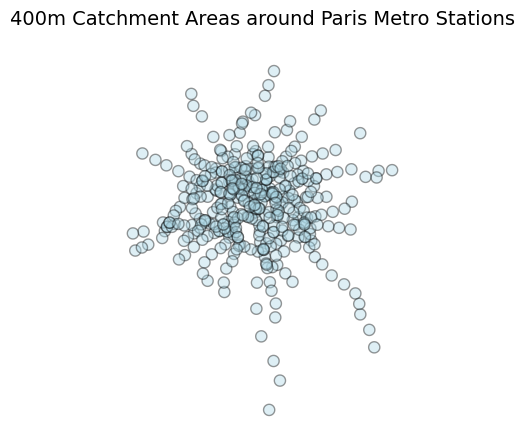

In [6]:
#CREATE THE BUFFERS
station_buffers = create_buffers(stations, 400)

#CREATE A STATIC MAP FOR CHECK-UP
fig, ax = plt.subplots(figsize=(5, 5))
station_buffers.plot(
    ax=ax,
    alpha=0.4,
    edgecolor="black",
    color="lightblue"
)
ax.set_title("400m Catchment Areas around Paris Metro Stations", fontsize=14)
ax.set_axis_off()
plt.savefig("../outputs/3_FIG_Buffers.png", dpi=300, bbox_inches="tight")
plt.show()

#CREATE AN INTERACTIVE HTML MAP (SEE OUTPUTS)
m = station_buffers.explore()
m.save("../outputs/3_MAP_BuffersNetwork.html")




In [35]:
#Extract income values from raster
station_buffers_income = extract_mean_raster_value(
    station_buffers,
    raster_path=income_raster_path,
    value_column="income_mean"
)
station_buffers_income["income_mean"].isna().sum()
station_buffers_income["income_mean"].describe()

count      405.000000
mean     32090.091525
std       5849.811193
min      18313.011719
25%      27469.699219
50%      31509.312500
75%      36741.550781
max      43928.445312
Name: income_mean, dtype: float64

Plausibility check: inspect the location of the highest- and lowest-income stations.

In [ ]:
# 10 richest Stations
top_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=False
).head(10)

top_stations[["nom_gares", "income_mean"]]

,nom_gares,income_mean
721,Villiers,43928.445312
459,Monceau,43928.445312
225,Villiers,43928.445312
973,Courcelles,43458.015625
1080,Ternes,43458.015625
637,Les Sablons,43418.925781
126,Pont de Neuilly,42334.253906
119,Malesherbes,42277.973958
842,Charles De Gaulle-Étoile,41560.910156
462,Rome,41520.932292


In [9]:
# 10 Poorest Stations
bottom_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=True
).head(10)

bottom_stations[["nom_gares", "income_mean"]]

,nom_gares,income_mean
710,Aimé Césaire,18313.011719
969,Mairie d'Aubervilliers,18417.355469
677,Front Populaire,19201.949219
1179,La Courneuve 8 Mai 1945,19211.029297
1182,Fort d'Aubervilliers,19592.882812
856,Saint-Denis - Porte de Paris,20616.679688
857,Saint-Denis - Université,20719.195312
177,Aubervilliers Pantin - Quatre Chemins,20766.644531
472,Basilique de Saint-Denis,20913.832031
1117,Bobigny Pablo Picasso,21301.837891


INTERPRETATION: Since the richest stations are concentrated in the inner northwest of Paris and the poorest stations around the north-eastern banlieu, the result seems to be plausible

# 4. Analysis
The following chapter conducts the spatial analysis for income and inequality

## 4.1 Income Distribution
The first analysis will focus on the broad stats of the analysis, showing the number of grid cells per station, the distribution of income by interval, and a heatmap showing these intervals.

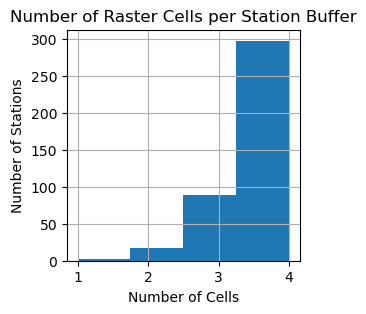

The minimum grid cells per station are: 1
The maximum grid cells per station are: 4


In [ ]:
#4.1.1 Create a graph, showing the number of gridcells per station
plt.figure(figsize=(3,3))
station_buffers_income["n_cells"].hist(bins=4)
plt.title("Number of Raster Cells per Station Buffer")
plt.xlabel("Number of Cells")
plt.ylabel("Number of Stations")
plt.savefig("../outputs/4_1_1_FIG_CellsPerRaster.png", dpi=300, bbox_inches="tight")
plt.show()

#Print the Min and Max
min_cells = station_buffers_income["n_cells"].min()
max_cells = station_buffers_income["n_cells"].max()
print(f"The minimum grid cells per station are: {min_cells}")
print(f"The maximum grid cells per station are: {max_cells}")

INTERPRETATION: The majority of station buffers intersect with four income raster grid cells.

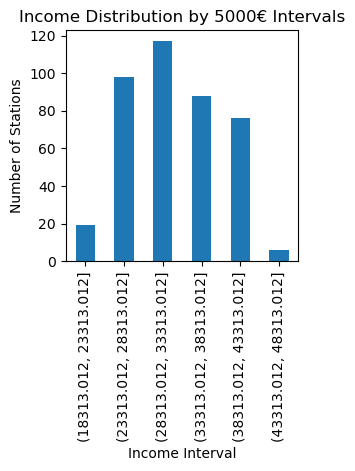

In [ ]:
#4.1.2 Distribution of Income Intervals
df = station_buffers_income.dropna(subset=["income_mean"]).copy()
min_income = df["income_mean"].min()
max_income = df["income_mean"].max()

# Create income intervals based on the minimum mean income in €5,000 steps
interval_width = 5000
n_intervals = int((max_income - min_income) / interval_width) + 1
bins = [min_income + i * interval_width for i in range(n_intervals + 1)]
df["income_interval"] = pd.cut(df["income_mean"], bins=bins)

#Set the Dataframe
interval_distribution = df["income_interval"].value_counts().sort_index()
interval_distribution.plot(kind="bar", figsize=(3,3))

#Plot 
plt.title("Income Distribution by 5000€ Intervals")
plt.xlabel("Income Interval")
plt.ylabel("Number of Stations")
plt.xticks(rotation=90)
plt.savefig("../outputs/4_1_2_FIG_IncomeIntervals.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: The distribution is approximately bell-shaped and right-skewed.

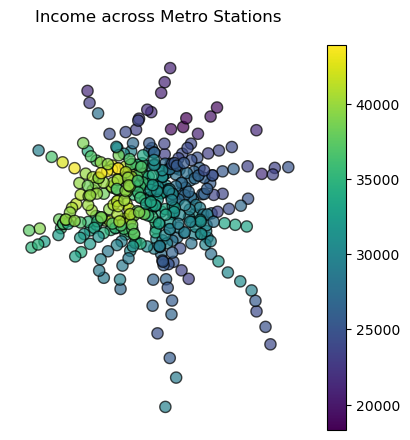

In [ ]:
#Create a heatmap showing the income levels

fig, ax = plt.subplots(figsize=(5,5))
df.plot(
    column="income_mean",
    cmap="viridis",
    legend=True,
    ax=ax,
    edgecolor="black",
    alpha=0.7
)
ax.set_title("Income across Metro Stations")
ax.set_axis_off()
plt.savefig("../outputs/4_1_2_FIG_IncomeHeatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
#Create an interactive HTML Heat Map
df_map = df[["nom_gares", "indice_lig", "income_mean", "geometry"]].copy()
m = df_map.explore(
    column="income_mean",
    cmap="viridis"
)
m.save("../outputs/4_1_3_MAP_income_per_station.html")

INTERPRETATION: The heatmap confirms the intuition, that the stations in the inner west have on average a higher disposable income, while the rest of Paris is in the middle region, with the north-eastern edges and some parts of the banlieu being the lowest income group.

Funfact: The map looks very similar to the latest 2026 election map which can be seen here: https://cdn.paris.fr/paris/2026/03/23/original-d3c6ce5863b0e898d4d156ece7ea7d23.png

## 4.2 Grouping Stations by Line
The stations are now grouped by line to conduct line-based analysis.

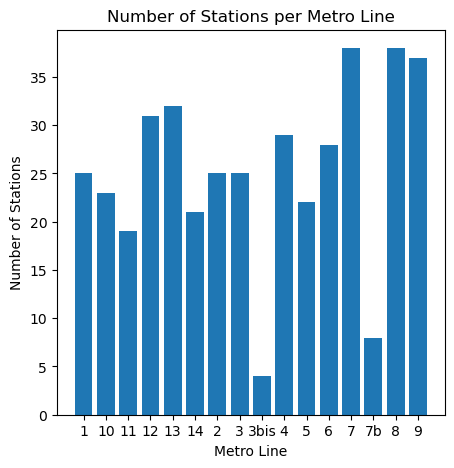

In [14]:
#Sorting the Lines
stations_per_line = df.groupby("indice_lig").size().reset_index(name="n_stations")
stations_per_line = stations_per_line.sort_values(by="indice_lig")

#Plot the histogram with the number of stations per metro line
plt.figure(figsize=(5,5))
plt.bar(
    stations_per_line["indice_lig"],
    stations_per_line["n_stations"]
)
plt.title("Number of Stations per Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Number of Stations")
plt.savefig("../outputs/4_2_FIG_CellsPerRaster.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
#Set a filter for 10 or more stations to exclude the branch lines
filtered = stations_per_line[
    stations_per_line["n_stations"] >= 10
].copy()

min_stations = filtered["n_stations"].min()
max_stations = filtered["n_stations"].max()
mean_stations = filtered["n_stations"].mean()

#Print the Minimum and Maximum stations per line + the average
print(f"Line with the least stations: {min_stations}")
print(f"Line with the most stations: {max_stations}")
print(f"Average stations per line: {mean_stations:.2f}")

Line with the least stations: 19
Line with the most stations: 38
Average stations per line: 28.07


INTERPRETATION: Beside the two branch lines 3bis and 7b, the stations are in a range of 19-38, with an average of 28 stations.

## 4.3 Income per Line
The grouped lines are now sorted by their average income.


Average income per metro line :


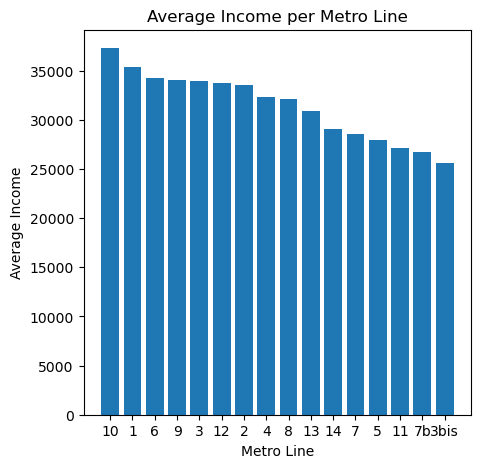

Line 10: 37324.34
Line 1: 35431.40
Line 6: 34256.04
Line 9: 34046.62
Line 3: 33998.22
Line 12: 33748.92
Line 2: 33584.63
Line 4: 32383.47
Line 8: 32130.90
Line 13: 30922.72
Line 14: 29105.43
Line 7: 28625.33
Line 5: 28002.73
Line 11: 27185.89
Line 7b: 26745.46
Line 3bis: 25601.61


In [16]:
#Average Income
line_income = df.groupby("indice_lig")["income_mean"].mean().reset_index()
line_income = line_income.rename(columns={"income_mean": "mean_income"})

#Sort by value
line_income["line_num"] = line_income["indice_lig"].str.extract(r"(\d+)").astype(int)
line_income = line_income.sort_values(by=["mean_income"], ascending=False)

#Plot a barchart showing the income per line
plt.figure(figsize=(5,5))
plt.bar(
    line_income["indice_lig"],
    line_income["mean_income"]
)

plt.title("Average Income per Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Average Income")
plt.xticks(rotation=0)
plt.savefig("../outputs/4_3_FIG_incomePerLine.png", dpi=300, bbox_inches="tight")
print("\nAverage income per metro line :")
plt.show()

#Print Loop for the Average income per metro line
for _, row in line_income.iterrows():
    print(f"Line {row['indice_lig']}: {row['mean_income']:.2f}")

INTERPRETATION: One can observe, that the two branch lines have the lowest income. 
Among the non-branch lines, line 11 has the lowest mean income, Line 10 has the highest income.

In [ ]:
## Add the income to the metro lines dataset
metro_lines_paris["indice_lig"] = metro_lines_paris["ref"].astype(str)
metro_lines_income = metro_lines_paris.merge(
    line_income,
    on="indice_lig",
    how="left"
)

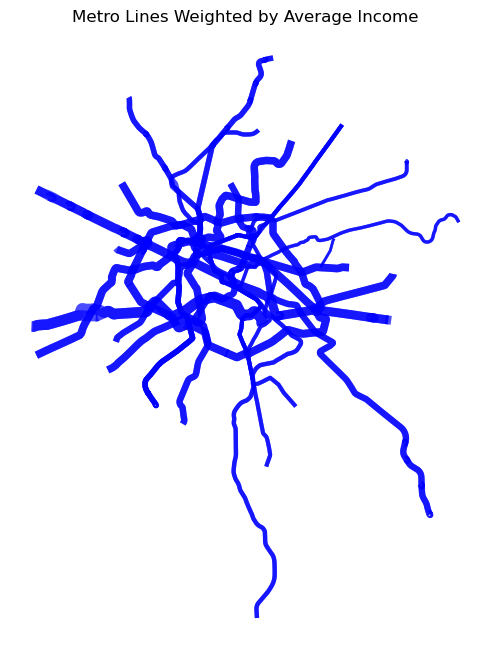

In [ ]:
#Creating a map that shows the lines with the width according to the income
metro_lines_income["line_width"] = (
    ((metro_lines_income["mean_income"] - min_income) / (max_income - min_income)) ** 2
) * 12 + 1

#Plot the width map
fig, ax = plt.subplots(figsize=(8,8))
for _, row in metro_lines_income.iterrows():
    gpd.GeoSeries([row.geometry], crs=metro_lines_income.crs).plot(
        ax=ax,
        linewidth=row["line_width"],
        color="blue",
        alpha=0.7
    )
ax.set_title("Metro Lines Weighted by Average Income")
ax.set_axis_off()
plt.savefig("../outputs/4_3_FIG_LinesWeighted.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
#Create an Interactive Map, colorgrading the lines
m = metro_lines_income.explore(
    column="mean_income",
    cmap="viridis"
)
m.save("../outputs/4_3_MAP_income_lines.html")

## 4.4 Inequality per Line
Several statistical methods can be used to measure inequality per line.
In this analysis, the following measures are used:

- 4.4.1 Standard Deviation
- 4.4.2 Interquartile Range
- 4.4.3 Gini Coefficient 
- 4.4.2 Range

## 4.4.1 Standard Deviation
The standard deviation is the most "classic" analysis, measuring how much the values are spread around the average

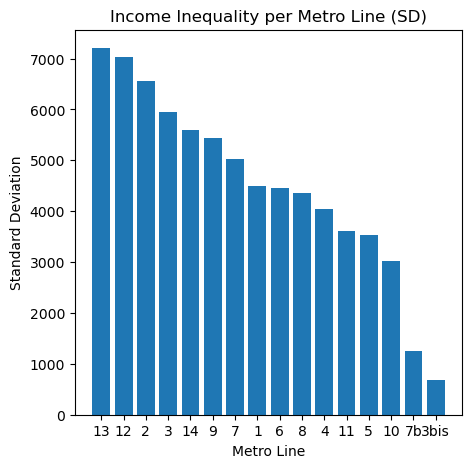

In [39]:
#Calculate the SDV for the mean income
line_std = df.groupby("indice_lig")["income_mean"].std().reset_index()
line_std = line_std.rename(columns={"income_mean": "std_income"})
line_std = line_std.sort_values(by="std_income", ascending=False)

#Plot the SDV per line
plt.figure(figsize=(5,5))
plt.bar(
    line_std["indice_lig"],
    line_std["std_income"]
)
plt.title("Income Inequality per Metro Line (SD)")
plt.xlabel("Metro Line")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=0)
plt.savefig("../outputs/4_4_1_FIG_Inequality_SD.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: The standard deviation shows clear differences, with branch lines unsurprisingly having the lowest SDV. They are followed by lines that mostly operate in central Paris and only marginally in the banlieue. In contrast, the lines with the highest SDV, 13 and 12, run from banlieue to banlieue in a north–south direction, passing through Paris via higher-income stations. Line 2 is an exception, as it runs in central Paris but connects a similar pattern from middle- to low- to high-income areas within the city.

## 4.4.2 IQR (Interquartile Range)
The next measure is the interquartile range. The interquartile range (IQR) is the difference between the 75th and 25th percentile, showing how spread out the middle 50% of the data is.

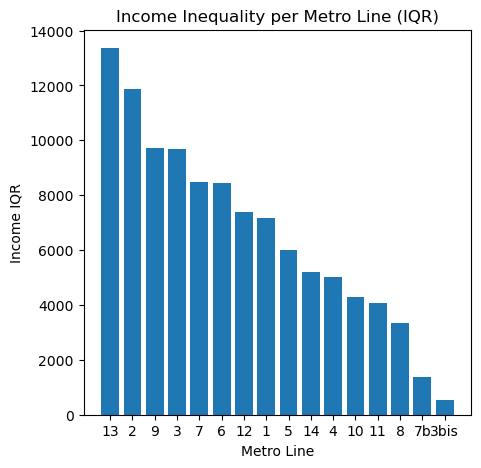

In [21]:
#Calculate IQR
line_iqr = df.groupby("indice_lig")["income_mean"].quantile([0.25, 0.75]).unstack()
line_iqr["iqr"] = line_iqr[0.75] - line_iqr[0.25]
line_iqr = line_iqr.reset_index()[["indice_lig", "iqr"]]
line_iqr = line_iqr.sort_values(by="iqr", ascending=False)

plt.figure(figsize=(5,5))
plt.bar(
    line_iqr["indice_lig"],
    line_iqr["iqr"]
)
plt.title("Income Inequality per Metro Line (IQR)")
plt.xlabel("Metro Line")
plt.ylabel("Income IQR")
plt.xticks(rotation=0)
plt.savefig("../outputs/4_4_2_FIG_Inequality_SD.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: Lines 13 and 2 again show high inequality. On the other hand, line 12, which previously exhibited high inequality, now lies almost exactly in the middle in terms of IQR.

## 4.4.3 Gini
The Gini coefficient measures inequality by comparing the observed distribution to a perfectly equal distribution, by conducting a geometric ratio of the area between the perfect and the actual distribution to the area of the perfect distribution in the graph.

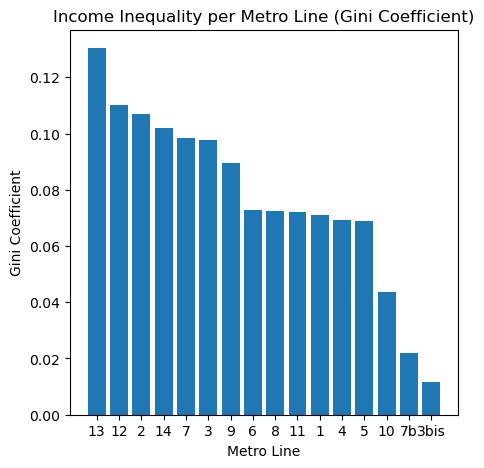

In [22]:
#Calculate the Gini Coefficent

#Calculate the Gini Function
def gini(x):
    x = np.sort(x)
    n = len(x)
    if np.sum(x) == 0:
        return 0
    return (2 * np.sum((np.arange(1, n+1) * x)) / (n * np.sum(x))) - (n + 1) / n

#Apply the Gini Function to the dataframe
line_gini = df.groupby("indice_lig")["income_mean"].apply(gini).reset_index()
line_gini = line_gini.rename(columns={"income_mean": "gini"})
line_gini = line_gini.sort_values(by="gini", ascending=False)

#Plot the Gini Inequality
plt.figure(figsize=(5,5))
plt.bar(
    line_gini["indice_lig"],
    line_gini["gini"]
)
plt.title("Income Inequality per Metro Line (Gini Coefficient)")
plt.xlabel("Metro Line")
plt.ylabel("Gini Coefficient")
plt.xticks(rotation=0)
plt.savefig("../outputs/4_4_3_FIG_Inequality_GINI.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: The Gini coefficient confirms the standard deviation, with 13,12 and 2 beeing the most unequal. 

## 4.4.4 Range
The range is a simple measure that describes the difference between the highest and lowest incomes.

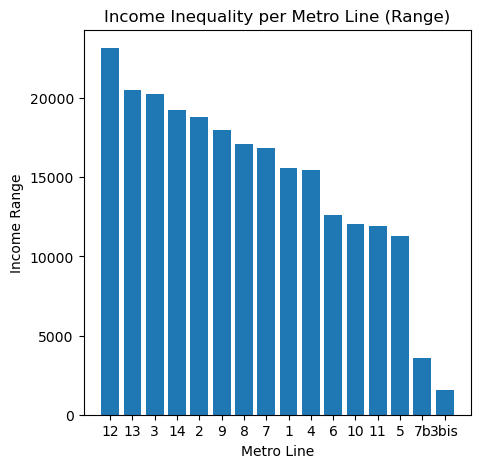

In [23]:
#Calculating Range
line_range = df.groupby("indice_lig")["income_mean"].agg(lambda x: x.max() - x.min()).reset_index()
line_range = line_range.rename(columns={"income_mean": "range_income"})
line_range = line_range.sort_values(by="range_income", ascending=False)

#Plot the range graph
plt.figure(figsize=(5,5))
plt.bar(
    line_range["indice_lig"],
    line_range["range_income"]
)
plt.title("Income Inequality per Metro Line (Range)")
plt.xlabel("Metro Line")
plt.ylabel("Income Range")
plt.xticks(rotation=0)
plt.savefig("../outputs/4_4_4_FIG_Inequality_Range.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: Despite being the least “statistical” measure, the range gap confirms lines 13 and 12 as the most unequal. Line 3, which was previously also in the upper quartiles of inequality, has the third-highest gap.

## 4.4.5 Conclusion 
For the conclusion on inequality, the different measures are compared.

In [24]:
#Merge Data
line_stats = line_income.merge(line_std, on="indice_lig")
line_stats = line_stats.merge(line_iqr, on="indice_lig")
line_stats = line_stats.merge(line_gini, on="indice_lig")
line_stats = line_stats.merge(line_range, on="indice_lig")

#Print Loops for income and (un)equality:
for col in ["std_income", "iqr", "gini", "range_income"]:
    print(f"\n {col.upper()} ")
    print("\nMost unequal lines:")
    print(line_stats.nlargest(5, col)[["indice_lig", col]].to_string(index=False))
    print("\nMost equal lines:")
    print(line_stats.nsmallest(5, col)[["indice_lig", col]].to_string(index=False))


 STD_INCOME 

Most unequal lines:
indice_lig  std_income
        13 7207.513778
        12 7040.051321
         2 6554.664005
         3 5946.620600
        14 5589.912178

Most equal lines:
indice_lig  std_income
      3bis  679.546854
        7b 1262.184055
        10 3021.332121
         5 3528.895074
        11 3618.038348

 IQR 

Most unequal lines:
indice_lig          iqr
        13 13364.755859
         2 11868.765625
         9  9711.641927
         3  9694.341146
         7  8480.239258

Most equal lines:
indice_lig         iqr
      3bis  523.527181
        7b 1388.562500
         8 3357.019531
        11 4080.532227
        10 4299.140625

 GINI 

Most unequal lines:
indice_lig     gini
        13 0.130383
        12 0.109964
         2 0.106860
        14 0.101861
         7 0.098545

Most equal lines:
indice_lig     gini
      3bis 0.011740
        7b 0.022049
        10 0.043626
         5 0.068990
         4 0.069161

 RANGE_INCOME 

Most unequal lines:
indice_lig  rang

Lines 13, 12, and 5 are the most unequal across the different measures. The branch lines are unsurprisingly the most equal, followed by 10, 5, and 11.

# 5. Regression
The goal of this exercise is to investigate selected lines and assess whether a relationship can be observed between income and distance from the center. Since no open-source dataset includes the exact kilometer point of each station along the line, a workaround is required. From the available station dataset, the most useful variables are therefore likely the coordinates, combined with some assumptions.

It is therefore necessary to choose lines in which either the x- or y-axis reflects distance from the center, meaning the alignment follows a north–south or east–west axis. Based on these characteristics, two lines are chosen:

- Metro Line 4 : A north–south axis. As shown below, the income characteristics of this line are such that the north and south fall into the lower quantiles, while the center lies in the upper and middle quantiles. The first instinct would therefore be that the income distribution follows a parabolic pattern.

- Metro Line 1: East–west axis: As shown below, one would assume a similar but less central distribution, where, starting from the east, the metro connects lower- and middle-income stations with westward-increasing income groups until it reaches its peak near Place Charles de Gaulle and then declines toward La Défense.

Both lines pass through the station Châtelet, which is taken as the center due to its geographic location and its importance as a central node in the Parisian transit system.
By nature, controlling only for distance introduces a high omitted variable bias. With more time, additional variables—especially housing prices and population density—would be included.

## 5.1 Reggression - North-South

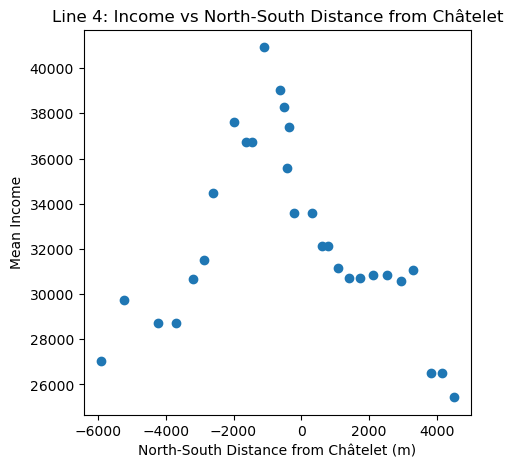

In [25]:
#Select Line 4, set Chatelet as center and calculate the distance of the y coordinate, indicating how north/south the station is:
line4 = df[df["indice_lig"] == "4"].copy()
center_y = stations[
    stations["nom_gares"].str.contains("Châtelet", case=False)
]["y"].iloc[0]
line4["y_dist"] = line4["y"] - center_y

#Create a Scatterplot
plt.figure(figsize=(5,5))
plt.scatter(
    line4["y_dist"],
    line4["income_mean"]
)
plt.title("Line 4: Income vs North-South Distance from Châtelet")
plt.xlabel("North-South Distance from Châtelet (m)")
plt.ylabel("Mean Income")
plt.savefig("../outputs/5_1_FIG_Scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: Income along Line 4 follows a spatial gradient that is not perfectly, but quite closely, centered around Chatelet, decreasing with distance from the center. Toward the north, income declines gradually before reaching a plateau—partly due to a high density of stations—then drops more sharply toward the final stations. Toward the south, income also decreases gradually, but it is clearly notable that the southern banlieue has higher income levels than the northern one.

In [26]:
#Build the regression model, based on a quadratic function
line4["y_dist_sq"] = line4["y_dist"] ** 2

#Describing Variable
X = line4[["y_dist", "y_dist_sq"]]
#Add Intercept
X = sm.add_constant(X)

#OLS
y = line4["income_mean"]
model_line4_quad = sm.OLS(y, X).fit()

#Print the OLS
print(model_line4_quad.summary())

                            OLS Regression Results                            
Dep. Variable:            income_mean   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     27.27
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           4.13e-07
Time:                        14:21:32   Log-Likelihood:                -265.14
No. Observations:                  29   AIC:                             536.3
Df Residuals:                      26   BIC:                             540.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.507e+04    590.032     59.438      0.0

INTERPRETATION: y_dist_ and y_dist_sq are negative and highly significant, the multicollinearity which is expected because the model includes both the linear and squared term of the same variable

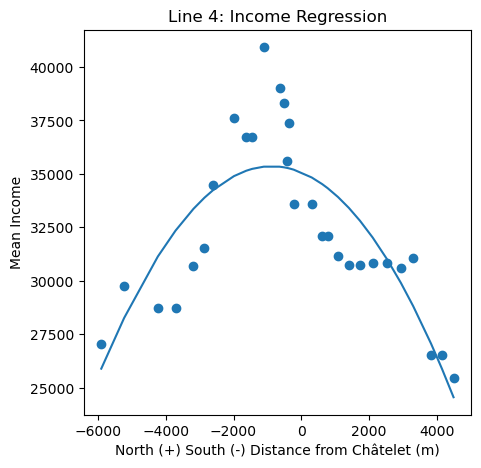

In [27]:
#Plot the Scatterplot with the Regressionline 

#Sort Data
line4_sorted = line4.sort_values(by="y_dist").copy()
X_sorted = line4_sorted[["y_dist", "y_dist_sq"]]
X_sorted = sm.add_constant(X_sorted)

#Scatterplot
plt.figure(figsize=(5,5))
plt.scatter(
    line4["y_dist"],
    line4["income_mean"]
)
plt.plot(
    line4_sorted["y_dist"],
    model_line4_quad.predict(X_sorted)
)
plt.title("Line 4: Income Regression")
plt.xlabel("North (+) South (-) Distance from Châtelet (m)")
plt.ylabel("Mean Income")
plt.savefig("../outputs/5_1_FIG_Regression.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: Income along Line 4 follows a clear non-linear spatial pattern, with the highest values near the city center and progressively lower values toward the periphery. The model appears to struggle to predict the exceptionally high incomes in the southern central area of Paris.

## 5.2 Regression - West-East

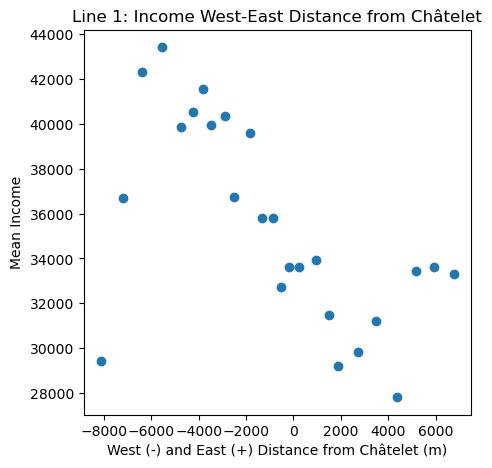

In [28]:
#Select Line 1, set Chatelet as center and calculate the distance of the x coordinate, indicating how west/east the station is
line1 = df[df["indice_lig"] == "1"].copy()
center_x = stations[
    stations["nom_gares"].str.contains("Châtelet", case=False)
]["x"].iloc[0]
line1["x_dist"] = line1["x"] - center_x

#Scatterplot
plt.figure(figsize=(5,5))
plt.scatter(
    line1["x_dist"],
    line1["income_mean"]
)
plt.title("Line 1: Income West-East Distance from Châtelet")
plt.xlabel("West (-) and East (+) Distance from Châtelet (m)")
plt.ylabel("Mean Income")
plt.savefig("../outputs/5_2_1_FIG_Scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: In contrast to Line 4, Line 1 looks less centered and less smooth. Chatelete is, in comparison to the whole magnitude, of moderate income while the magnitude increases rapidly going westwards before it drops harsh over the last 2 stations. Eastwards the income decreases as expected first quite linear, before it increases drastically reaching the banlieu
In the following analysis, Line 1 will be filtered to include only the stations within Paris, in order to estimate a linear regression model for the paris city area.

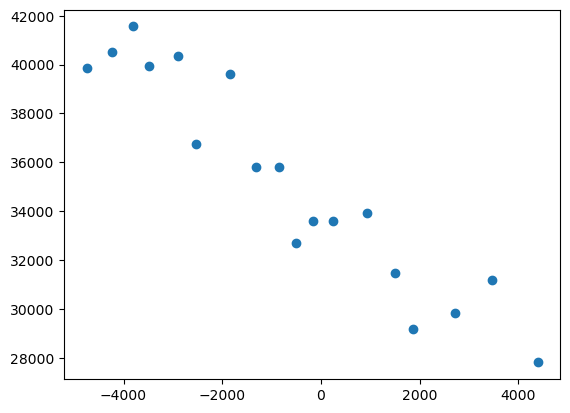

In [ ]:
## Filter for stations inside core Paris (excluding the first suburban stations)

#Manually selected stations
west_cut = line1[line1["nom_gares"] == "Les Sablons"]["x_dist"].iloc[0]
east_cut = line1[line1["nom_gares"] == "Saint-Mandé"]["x_dist"].iloc[0]

line1_paris = line1[
    (line1["x_dist"] > west_cut) &
    (line1["x_dist"] < east_cut)
].copy()

#Updated Scatterplot
plt.scatter(
    line1_paris["x_dist"],
    line1_paris["income_mean"]
)
plt.savefig("../outputs/5_1_2_FIG_Scatterplot_filtered.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: Limiting the station areas to those within Paris yields a much clearer picture, with a clearly noticeable linear trend of decreasing income eastward. Based on the “in Paris” filter, a linear regression will be conducted in the following.

In [30]:
#Regression and Summary Stats

X = line1_paris["x_dist"]
y = line1_paris["income_mean"]
X = sm.add_constant(X)
model_line1_lin = sm.OLS(y, X).fit()
print(model_line1_lin.summary())

                            OLS Regression Results                            
Dep. Variable:            income_mean   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     135.8
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           3.14e-09
Time:                        14:21:33   Log-Likelihood:                -155.66
No. Observations:                  18   AIC:                             315.3
Df Residuals:                      16   BIC:                             317.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.425e+04    354.030     96.746      0.0

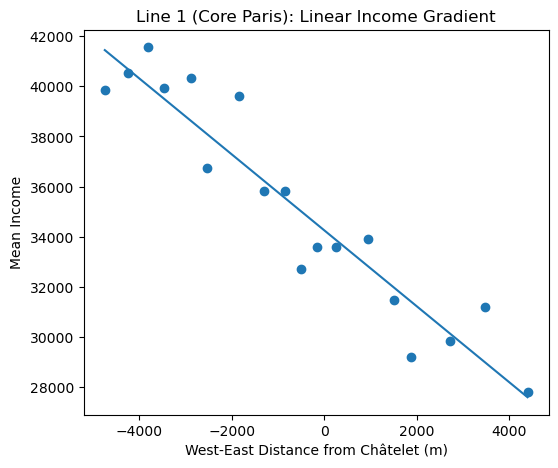

In [31]:
#Plot Regression
line1_sorted = line1_paris.sort_values(by="x_dist")
plt.figure(figsize=(6,5))
plt.scatter(
    line1_paris["x_dist"],
    line1_paris["income_mean"]
)
plt.plot(
    line1_sorted["x_dist"],
    model_line1_lin.predict(sm.add_constant(line1_sorted["x_dist"]))
)

plt.title("Line 1 (Core Paris): Linear Income Gradient")
plt.xlabel("West-East Distance from Châtelet (m)")
plt.ylabel("Mean Income")
plt.savefig("../outputs/5_2_2_FIG_Regression.png", dpi=300, bbox_inches="tight")
plt.show()

INTERPRETATION: Although the east–west regression is subject to the same statistical limitations (such as omitted variable bias) as the north–south regression, the model—filtered to core Paris—shows a much better fit. The east coefficient is negative, indicating that income decreases eastward, and it is highly significant.

# 6. Sensitivity Analysis

In the following, a sensitivity analysis is conducted, testing different buffer sizes. The aim is to assess whether and how different catchment areas change the results for income and inequality per line.

## 6.1 Setup
First, a dataframe for the sensitivity analysis is prepared.


In [32]:
#Defining the buffer sizes
buffer_sizes = [200, 300, 500, 600]

#Loop over buffer sizes
results = []
for b in buffer_sizes:
    
    # Create buffers
    buffers = create_buffers(stations, b)
    buffers_income = extract_mean_raster_value(
        buffers,
        raster_path=income_raster_path,
        value_column="income_mean"
    )
    
    # Statistics
    line_income = buffers_income.groupby("indice_lig")["income_mean"].mean().reset_index()
    line_std = buffers_income.groupby("indice_lig")["income_mean"].std().reset_index()
    line_std = line_std.rename(columns={"income_mean": "std_income"})
    
    # Merge
    stats = line_income.merge(line_std, on="indice_lig")
    stats["buffer"] = b
    results.append(stats)

sensitivity_df = pd.concat(results, ignore_index=True)


## 6.2 Income per Line
The first check is conducted for income.

In [ ]:
#Print Loop for 3 richest and 3 poorest lines per buffer size
for b in buffer_sizes:
    print(f"\n Buffer {b}m ")
    print("\n 3 richest lines:")
    print(
        sensitivity_df[sensitivity_df["buffer"] == b]
        .nlargest(3, "income_mean")[["indice_lig", "income_mean"]]
        .to_string(index=False)
    )
    print("\n 3 poorest lines:")
    print(
        sensitivity_df[sensitivity_df["buffer"] == b]
        .nsmallest(3, "income_mean")[["indice_lig", "income_mean"]]
        .to_string(index=False)
    )


 Buffer 200m 

 3 richest lines:
indice_lig  income_mean
        10 36698.877774
         1 35214.620026
         3 34328.379375

 3 poorest lines:
indice_lig  income_mean
      3bis 26122.412598
        7b 26414.784424
        11 27402.596183

 Buffer 300m 

 3 richest lines:
indice_lig  income_mean
        10 37386.292799
         1 35456.144661
         3 34436.970599

 3 poorest lines:
indice_lig  income_mean
      3bis 25461.623535
        7b 26366.004395
        11 27208.505585

 Buffer 500m 

 3 richest lines:
indice_lig  income_mean
        10 37179.909952
         1 35629.473594
         3 34382.345823

 3 poorest lines:
indice_lig  income_mean
      3bis 25698.299935
        7b 26589.058594
        11 27134.196731

 Buffer 600m 

 3 richest lines:
indice_lig  income_mean
        10 36761.553191
         1 35543.930801
         3 34268.097567

 3 poorest lines:
indice_lig  income_mean
      3bis 25723.240118
        7b 26751.752500
        11 27089.550875


INTERPRETATION: 

## 6.2 Inequality
The second test is conducted for inequality.

In [ ]:
#Print loop for 3 least unequal and 3 most unequal lines
for b in buffer_sizes:
    print(f"\n Buffer {b}m ")
    print("\n 3 most unequal lines (STD)")
    print(
        sensitivity_df[sensitivity_df["buffer"] == b]
        .nlargest(3, "std_income")[["indice_lig", "std_income"]]
        .to_string(index=False)
    )
    
    print("\n 3 least unequal lines (STD)")
    print(
        sensitivity_df[sensitivity_df["buffer"] == b]
        .nsmallest(3, "std_income")[["indice_lig", "std_income"]]
        .to_string(index=False)
    )


 Buffer 200m 

 3 most unequal lines (STD)
indice_lig  std_income
        12 7382.576845
        13 7343.548852
         2 6600.498655

 3 least unequal lines (STD)
indice_lig  std_income
      3bis 1491.651269
        7b 1997.850836
        10 3369.636531

 Buffer 300m 

 3 most unequal lines (STD)
indice_lig  std_income
        13 7251.208048
        12 7154.213616
         2 6721.082846

 3 least unequal lines (STD)
indice_lig  std_income
      3bis  952.421315
        7b 1237.185020
        10 3316.190232

 Buffer 500m 

 3 most unequal lines (STD)
indice_lig  std_income
        13 7259.682743
        12 6905.831445
         2 6494.690663

 3 least unequal lines (STD)
indice_lig  std_income
      3bis  524.697428
        7b 1244.501897
        10 2845.614420

 Buffer 600m 

 3 most unequal lines (STD)
indice_lig  std_income
        13 7057.032560
        12 6731.375693
         2 6166.854837

 3 least unequal lines (STD)
indice_lig  std_income
      3bis  600.257187
        7b 124

INTERPRETATION: Lines 13, 12, and 2 remain the most unequal across all buffer sizes. Metro Line 10 remains the least unequal for all buffer sizes as well, aside from the branch lines 3bis and 7b.

# 7. Conclusion

In this project, I was able to show which metro lines have the highest and lowest average income based on the income around their stations. The maps, especially the interactive ones, made it easy to see these patterns across Paris.

I also tested different buffer sizes to see if the results change. Overall, the main findings stay the same, so the results seem quite robust to the choice of catchment size.

If I had more time or would continue this analysis, I would improve a few things:

- Use walking-time based catchment areas instead of simple circular buffers
- Weight the income grid cells based on how much of them is actually covered
- Improve the regression by including more variables like density or housing prices

Overall, the project gives a solid first overview, but there is still room to make the analysis more realistic and more precise.